# First look at MUSE data

Eric has provided two data cubes and something else which is called MAPS, that just has a gradient and the footprint of the full cube. Here I'll start by opening up the fits files of the cubes to see how they are structured, maybe also plot the spectra in a few spaxels, etc

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cube 1
c30_cube_1 = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/MUSE/c30_cubes/c30_DATACUBE_normppxf_skycont_Part1_0000.fits')

In [3]:
c30_cube_1


[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x119f8d400>, <astropy.io.fits.hdu.image.ImageHDU object at 0x119f8ea50>, <astropy.io.fits.hdu.image.ImageHDU object at 0x119ffce10>, <astropy.io.fits.hdu.image.ImageHDU object at 0x119ffcf50>]

Now we know that there are 3 HDUs in here, a primary one and two image HDUs. ]

In [12]:
c30_cube_1.info()

Filename: /Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/MUSE/c30_cubes/c30_DATACUBE_normppxf_skycont_Part1_0000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    1691   ()      
  1  DATA          1 ImageHDU        46   (300, 300, 2457)   float32   
  2  STAT          1 ImageHDU        46   (300, 300, 2457)   float32   
  3  DQ            1 ImageHDU        45   (300, 300, 2457)   uint8   


# Primary HDU

In [4]:
c30_cube_1[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
DATE    = '2026-03-13 16:49:38.714608' / creation date                          
ORIGIN  = 'ESO-PARANAL'        / European Southern Observatory                  
TELESCOP= 'ESO-VLT-U4'         / ESO <TEL>                                      
INSTRUME= 'MUSE    '           / Instrument used.                               
RA      =            189.96498 / [deg] 12:39:59.4 RA (J2000) pointing           
DEC     =            -11.62302 / [deg] -11:37:22.9 DEC (J2000) pointing         
EQUINOX =                200

In [5]:
print(c30_cube_1[0].data)

None


# Secondary HDU

This seems to be the main data cube with the data that we want

In [6]:
c30_cube_1[1].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                  300                                                  
NAXIS2  =                  300                                                  
NAXIS3  =                 2457                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
WCSAXES =                    3 / Number of coordinate axes                      
CRPIX1  =      150.32971536211 / Pixel coordinate of reference point            
CRPIX2  =      150.77688636679 / Pixel coordinate of reference point            
CUNIT1  = 'deg'                / Units of coordinate increment and value        
CUNIT2  = 'deg'             

<>:13: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:13: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
/var/folders/__/n140hqf972zfmtt1hs5ldglw0000gn/T/ipykernel_9533/1620328969.py:13: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
  ax.set_title(f'Slice at {starting_wvl + 500*wvl_increment} $\AA$')


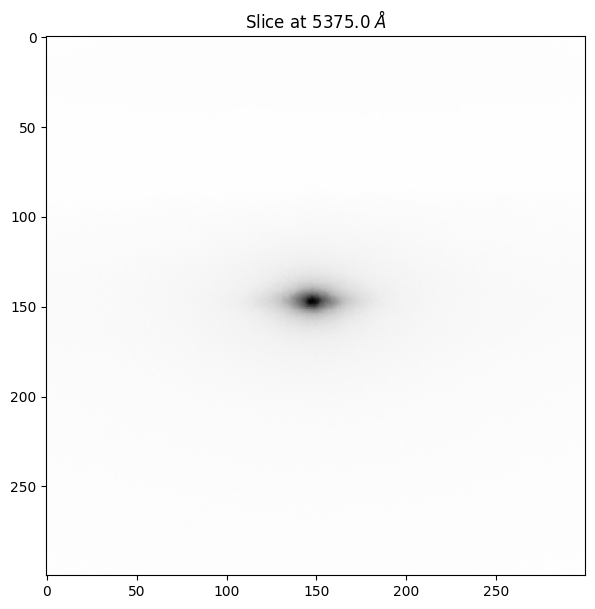

In [7]:
# which axis is the wavelenth?
c30_cube_1[1].data.shape

# we know that the first axis has the wavelengths and its likely a 300x300 spaxel image
# and we have 2457 wavelength units, starting at CRVAL3
starting_wvl = c30_cube_1[1].header['CRVAL3']
# and the increment is 
wvl_increment = c30_cube_1[1].header['CD3_3']

# lets plot the image in a random wavelenght
fig, ax = plt.subplots(1,1, figsize=(10,7))
ax.imshow(c30_cube_1[1].data[500], cmap='Grays')
ax.set_title(f'Slice at {starting_wvl + 500*wvl_increment} $\AA$')
plt.show()



In [8]:
len(spectra)*wvl_increment + starting_wvl

NameError: name 'spectra' is not defined

In [44]:
starting_wvl

4750.0

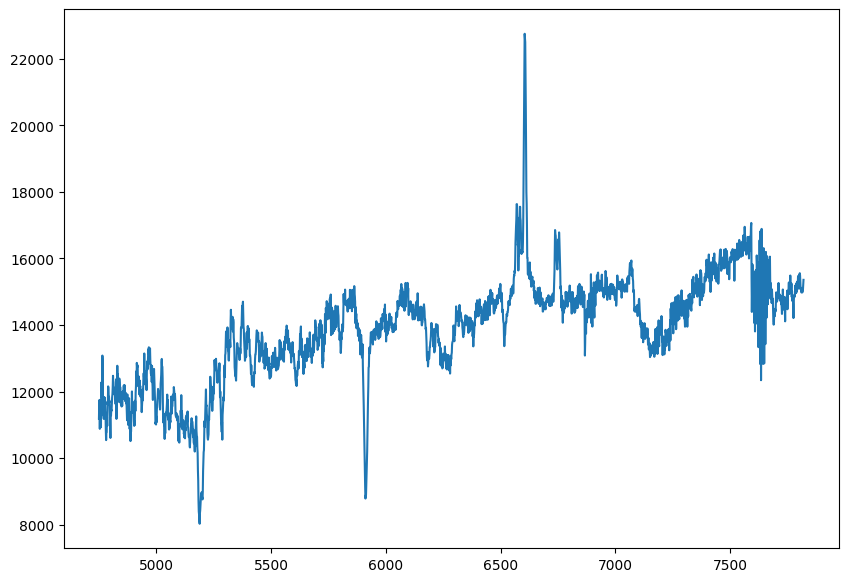

In [9]:
# plot the spectra for a random pixel
cube_muse = c30_cube_1[1].data

# lets get the pixel 150x 150
spectra = cube_muse[:, 150, 150]
wavelengths_spectra = np.arange(starting_wvl, len(spectra)*wvl_increment + starting_wvl, wvl_increment )

fig, ax = plt.subplots(1,1, figsize = (10, 7))
ax.plot(wavelengths_spectra, spectra)
plt.show()

# Third HDU

In [10]:
c30_cube_1[2].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                  300                                                  
NAXIS2  =                  300                                                  
NAXIS3  =                 2457                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
WCSAXES =                    3 / Number of coordinate axes                      
CRPIX1  =      150.32971536211 / Pixel coordinate of reference point            
CRPIX2  =      150.77688636679 / Pixel coordinate of reference point            
CUNIT1  = 'deg'                / Units of coordinate increment and value        
CUNIT2  = 'deg'             

This looks like a clone of the previous one

In [11]:
c30_cube_1[1].data == c30_cube_1[2].data

array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, Fal

It is not a clone of the previous one

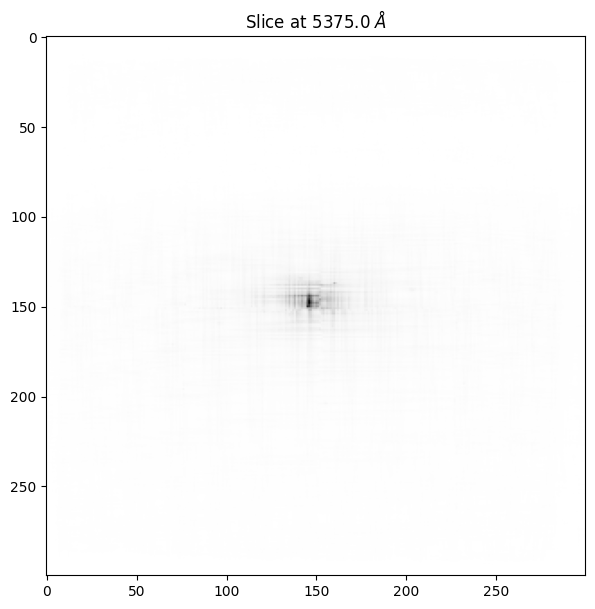

In [32]:
# which axis is the wavelenth?
c30_cube_1[2].data.shape

# we know that the first axis has the wavelengths and its likely a 300x300 spaxel image
# and we have 2457 wavelength units, starting at CRVAL3
starting_wvl = c30_cube_1[2].header['CRVAL3']
# and the increment is 
wvl_increment = c30_cube_1[2].header['CD3_3']

# lets plot the image in a random wavelenght
fig, ax = plt.subplots(1,1, figsize=(10,7))
ax.imshow(c30_cube_1[2].data[500], cmap='Grays')
ax.set_title(f'Slice at {starting_wvl + 500*wvl_increment} $\AA$')
plt.show()



wtf is this

# Lets look at the cube from the example so that we can put them in the same format

In [33]:
example_cube = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/ppxf_example/LVS_JWST_workshop_rodeo_cube.fits')

In [36]:
example_cube[0].data.shape

(3681, 30, 30)